In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1: Load Dataset

The dataset is loaded from the raw data folder. This step initializes the analysis by importing healthcare insurance data into a DataFrame.

In [28]:
df = pd.read_csv("../data/raw/healthcare_raw.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Insight:
The dataset contains information such as age, gender, BMI, smoking status, and insurance charges.

In [27]:
df.shape

(1338, 7)

In [28]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

2: Understand Dataset:

This step helps to understand the structure of the dataset, including data types, number of records, and statistical summary.

In [29]:
df.info

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [30]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Insight:

The dataset contains information such as age, gender, BMI, smoking status, and insurance charges.

3: Check Missing Values


In [31]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Insight:
- Missing values were found in the smoker column
- These values must be handled before further analysis

4: Handle Missing Values

In [32]:
df['smoker'] = df['smoker'].fillna('no')

5: Remove Duplicates

In [33]:
df.duplicated().sum()

np.int64(1)

In [34]:
df = df.drop_duplicates()

Insight:

Removing duplicates prevents biased or repeated data from affecting results.

6: Feature Engineering

Categorical variables are converted into numerical format to make them suitable for analysis.


In [10]:
# Fix warning
df = df.copy()

import pandas as pd

# 🔹 Encoding
df['sex'] = df['sex'].map({'male':1, 'female':0})
df['smoker'] = df['smoker'].map({'yes':1, 'no':0})

# 🔹 Age group (FIXED)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 30, 50, df['age'].max()],
    labels=['Young', 'Adult', 'Senior'],
    include_lowest=True
)

# 🔹 BMI category (FIXED)
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, df['bmi'].max()],
    labels=['Underweight', 'Normal', 'Overweight', 'Obese'],
    include_lowest=True
)

# 🔹 Family size
df['family_size'] = df['children'] + 1

In [36]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)
df.head()

,age,sex,bmi,children,smoker,charges,age_group,bmi_category,family_size,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,Young,Overweight,1,False,False,True
1,18,1,33.770,1,0,1725.55230,Young,Obese,2,False,True,False
2,28,1,33.000,3,0,4449.46200,Young,Obese,4,False,True,False
3,33,1,22.705,0,0,21984.47061,Adult,Normal,1,True,False,False
4,32,1,28.880,0,0,3866.85520,Adult,Overweight,1,True,False,False


In [37]:
df.head()

,age,sex,bmi,children,smoker,charges,age_group,bmi_category,family_size,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,Young,Overweight,1,False,False,True
1,18,1,33.770,1,0,1725.55230,Young,Obese,2,False,True,False
2,28,1,33.000,3,0,4449.46200,Young,Obese,4,False,True,False
3,33,1,22.705,0,0,21984.47061,Adult,Normal,1,True,False,False
4,32,1,28.880,0,0,3866.85520,Adult,Overweight,1,True,False,False


In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   age           1338 non-null   int64   
 1   sex           0 non-null      float64 
 2   bmi           1338 non-null   float64 
 3   children      1338 non-null   int64   
 4   smoker        0 non-null      float64 
 5   region        1338 non-null   object  
 6   charges       1338 non-null   float64 
 7   age_group     1338 non-null   category
 8   bmi_category  1338 non-null   category
 9   family_size   1338 non-null   int64   
dtypes: category(2), float64(4), int64(3), object(1)
memory usage: 86.7+ KB


Insight:
- Encoding helps in performing correlation and visualization
- Region is split into multiple columns using one-hot encoding

7.Univariate Analysis

7.1: Distribution of Charges 


- This plot shows how insurance charges are distributed across individuals.


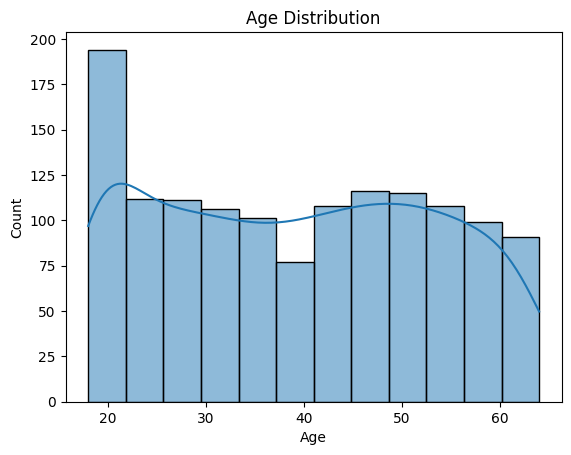

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Insight:
- Age is fairly evenly distributed across the dataset
- Majority of individuals fall within the 20–50 age range, indicating a balanced representation of young and middle-aged populations

7.2: BMI Distribution


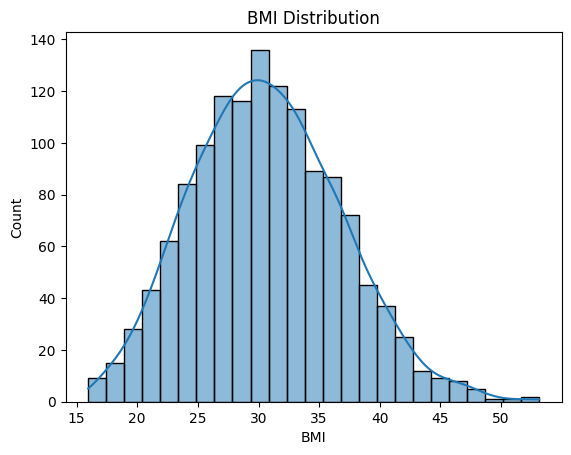

In [13]:
sns.histplot(df['bmi'], kde=True)
plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

Insight : 

- Most BMI values are concentrated between 20–35, indicating a predominantly normal to overweight population
- A few extreme BMI values suggest the presence of highly obese individuals

7.3 : Charges Distribution

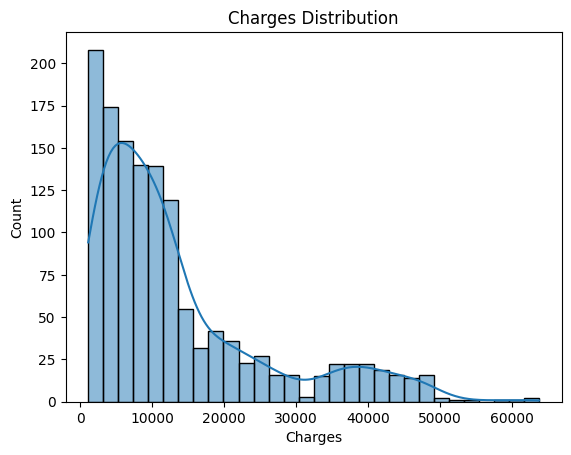

In [14]:
sns.histplot(df['charges'], kde=True)
plt.title("Charges Distribution")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

Insight :

- Insurance charges are highly right-skewed
- Majority of individuals incur lower medical costs, while a small group contributes to extremely high expenses

7.4 : Outlier Detection

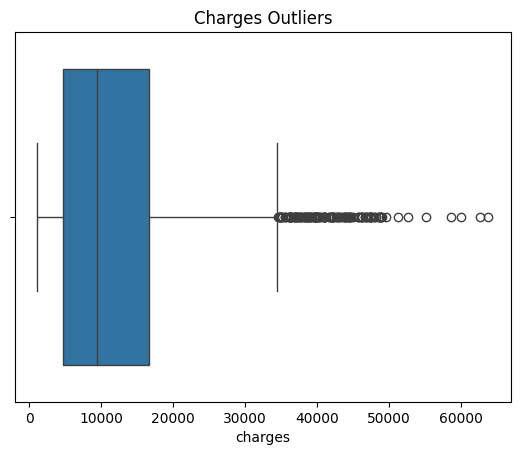

In [15]:
sns.boxplot(x=df['charges'])
plt.title("Charges Outliers")
plt.show()

Insight : 

- Significant number of outliers are present in the charges distribution
- These outliers represent high-cost patients, indicating unequal cost distribution

7.5 : Age Group

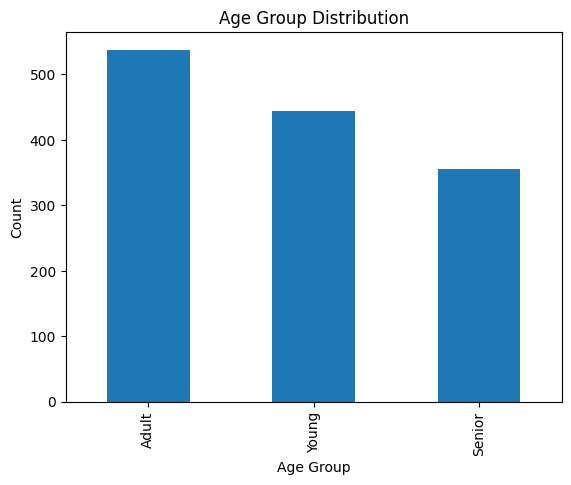

In [16]:
df['age_group'].value_counts().plot(kind='bar')
plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.show()

Insight : 

- The majority of individuals belong to the Adult age group
- Senior and Young groups have comparatively lower representation

7.6 : BMI Category

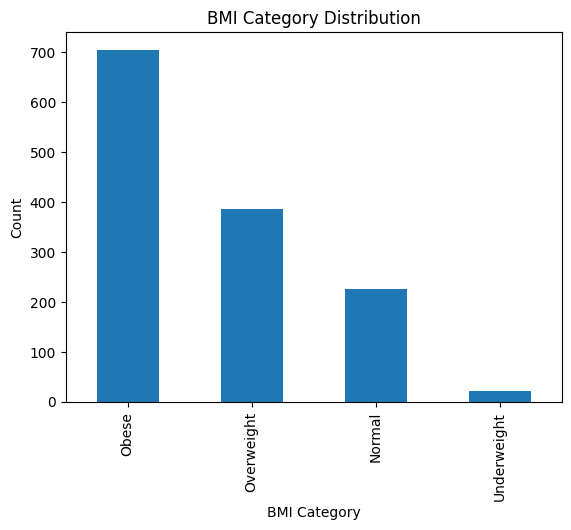

In [18]:
df['bmi_category'].value_counts().plot(kind='bar')
plt.title("BMI Category Distribution")
plt.xlabel("BMI Category")
plt.ylabel("Count")
plt.show()

Insight :

- A large proportion of individuals fall under the Obese category
- This indicates a potential health risk trend within the dataset

7.7 : Family Size

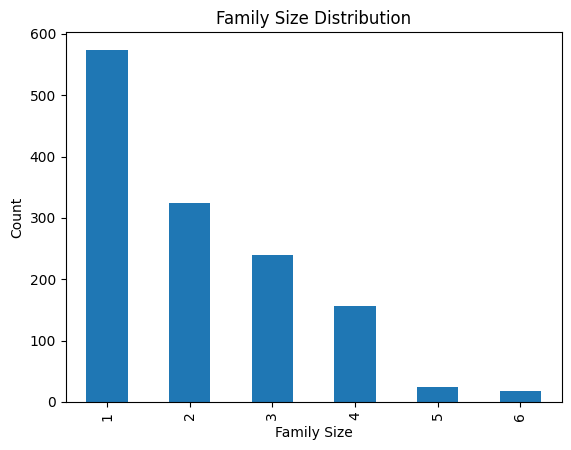

In [19]:
df['family_size'].value_counts().plot(kind='bar')
plt.title("Family Size Distribution")
plt.xlabel("Family Size")
plt.ylabel("Count")
plt.show()

Insight : 

- Most individuals have a family size of 1, indicating fewer dependents
- Larger family sizes (e.g., 6 members) are relatively rare

8: Bivariate Analysis



8.1 : smoker vs Charges


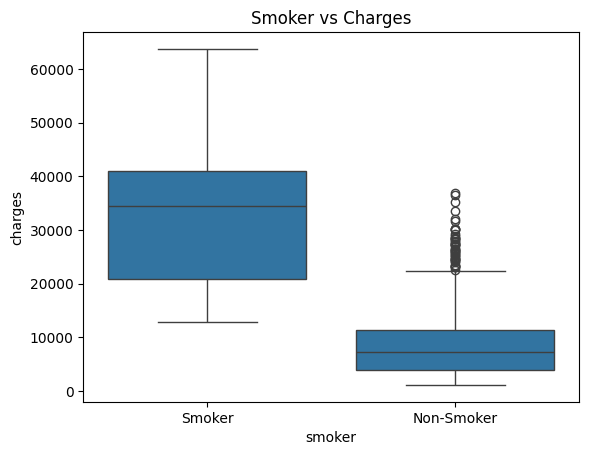

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['smoker'].map({1:'Smoker',0:'Non-Smoker'}),
            y=df['charges'])
plt.title("Smoker vs Charges")
plt.show()

Insight :

- Smokers have significantly higher medical charges compared to non-smokers
- Smoking is the most important factor influencing healthcare costs
- High-cost patients are mostly smokers

8.2 : Age vs Charges


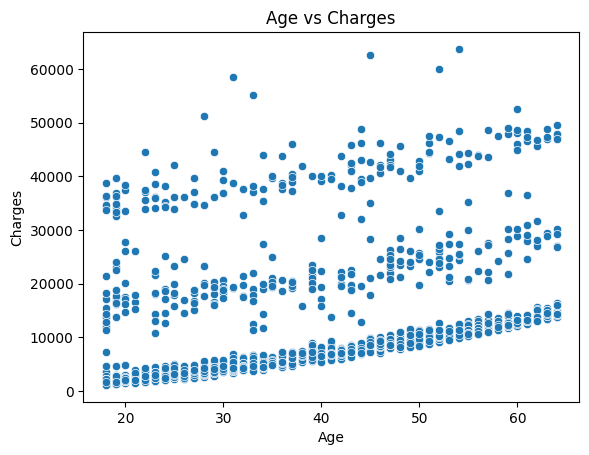

In [38]:
sns.scatterplot(x='age', y='charges', data=df)

plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

 Insight:

- Medical charges increase with age
- Older individuals tend to have higher healthcare expenses
- Younger individuals mostly have lower charges

8.3: BMI vs Charges


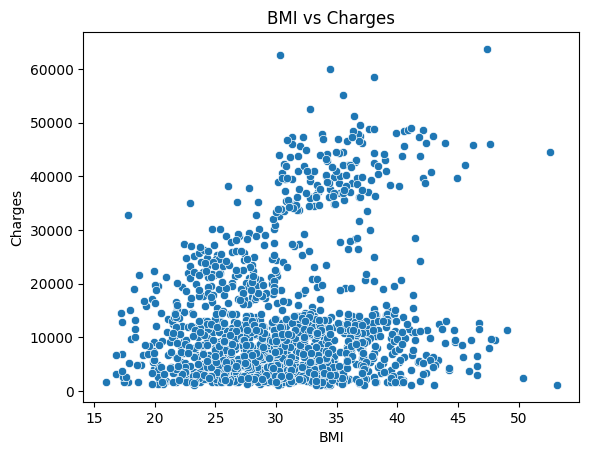

In [39]:
sns.scatterplot(x='bmi', y='charges', data=df)

plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

 Insight:

- Higher BMI is associated with higher medical costs
- Individuals with BMI above 30 (obese) tend to have higher expenses
- BMI has a moderate impact on charges

8.4 : Gender vs Charges

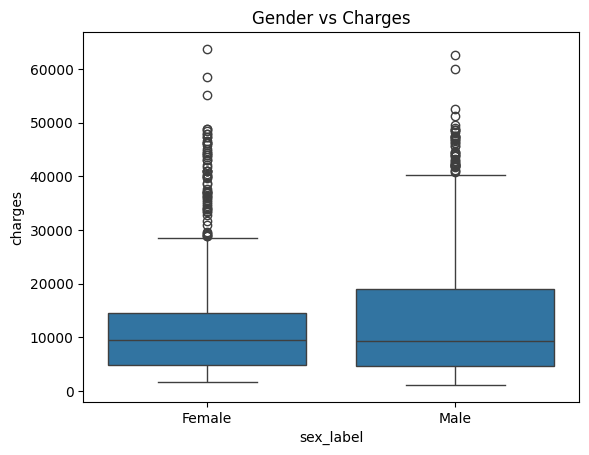

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='sex_label', y='charges', data=df)

plt.title("Gender vs Charges")
plt.show()

Insight : 

- There is no significant difference in medical charges between males and females
- Gender does not strongly influence healthcare costs

8.5 : Region vs Charges

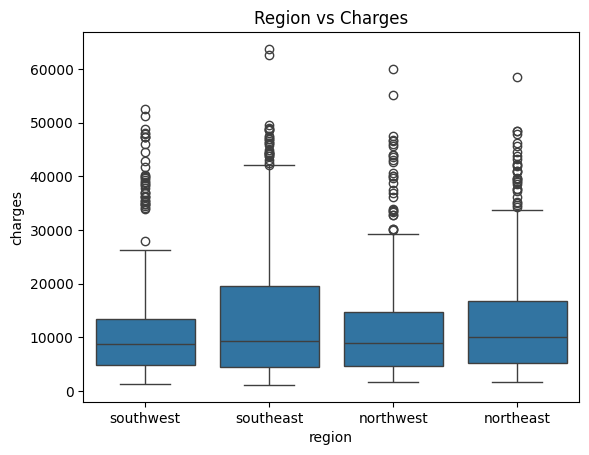

In [49]:
sns.boxplot(x='region', y='charges', data=df)

plt.title("Region vs Charges")
plt.show()

Insight :

- There are slight variations in charges across regions
- No region shows a very strong impact compared to other factors
- Regional differences are less significant

8.6 : Age Group vs Charges

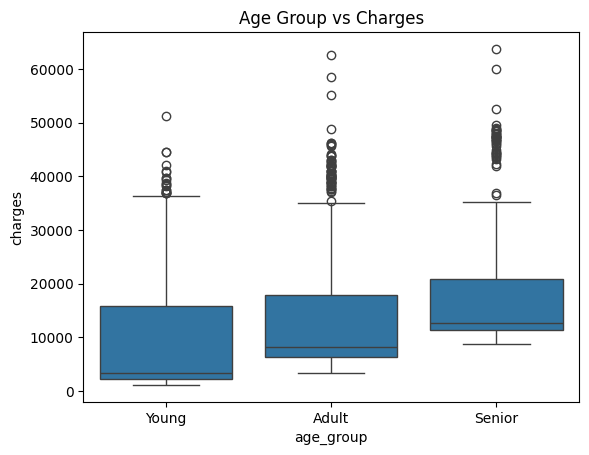

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='age_group', y='charges', data=df)

plt.title("Age Group vs Charges")
plt.show()

Insight : 

- Senior age group has the highest medical costs
- Adult group has moderate charges
- Young individuals have the lowest charges

8.7 : BMI Category vs Charges

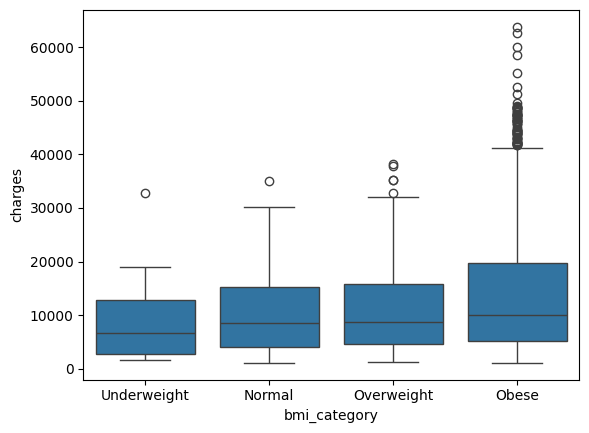

In [56]:
sns.boxplot(x='bmi_category', y='charges', data=df)
plt.show()

Insight :

- Obese individuals have the highest medical expenses
- Overweight individuals show moderate costs
- Normal BMI individuals have lower charges

9.Multivariate Analysis

Goal: Analyze 3 or more variables together

9.1 : Age + Smoker vs Charges

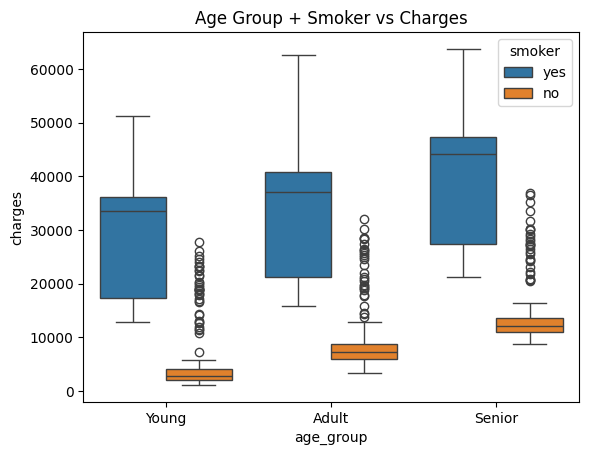

In [58]:
sns.boxplot(x='age_group', y='charges', hue='smoker', data=df)

plt.title("Age Group + Smoker vs Charges")
plt.show()

Insight : 

- Smokers in all age groups have higher medical costs than non-smokers
- Senior smokers incur the highest healthcare expenses
- Smoking impact is consistent across all age groups

9.2 : BMI + Smokers vs Charges

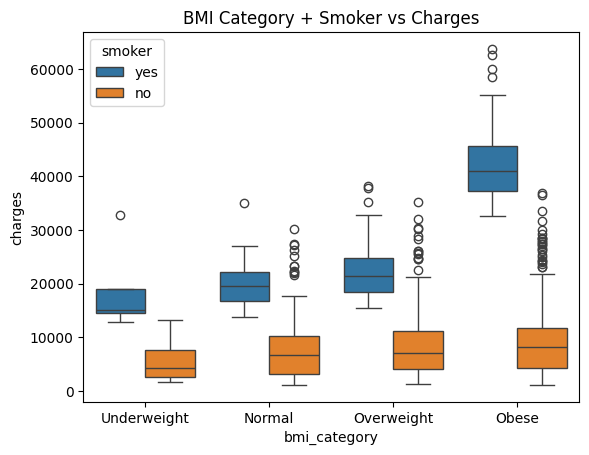

In [59]:
sns.boxplot(x='bmi_category', y='charges', hue='smoker', data=df)

plt.title("BMI Category + Smoker vs Charges")
plt.show()

Insight :

- Smokers with high BMI (obese) have the highest medical costs
- Non-smokers show lower charges across all BMI categories
- Combined effect of smoking and obesity increases expenses significantly

9.3 : Family Size vs Charges

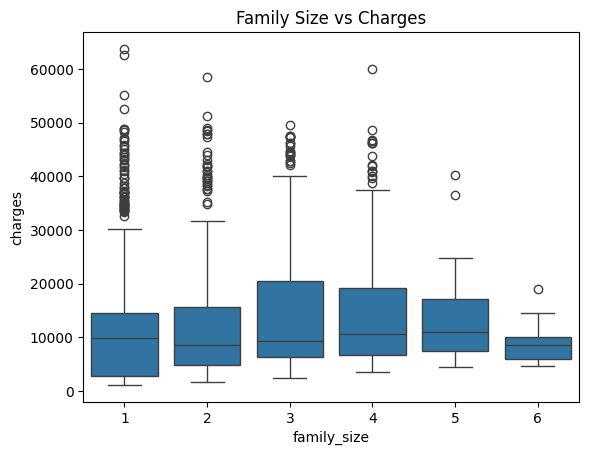

In [60]:
sns.boxplot(x='family_size', y='charges', data=df)

plt.title("Family Size vs Charges")
plt.show()

Insight :

- Family size has minimal impact on medical charges
- No strong pattern observed between family size and cost
- Charges are influenced more by health factors than family size

9.4: Correlation Heatmap


This heatmap shows relationships between numerical variables.

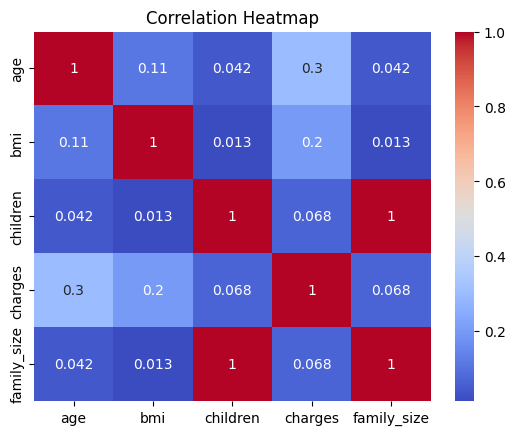

In [61]:
import seaborn as sns

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Insight:

- Charges have strong correlation with smoker
- Moderate correlation with age and BMI
- Weak correlation with children (family size)

9.5 : Correlation Heatmap

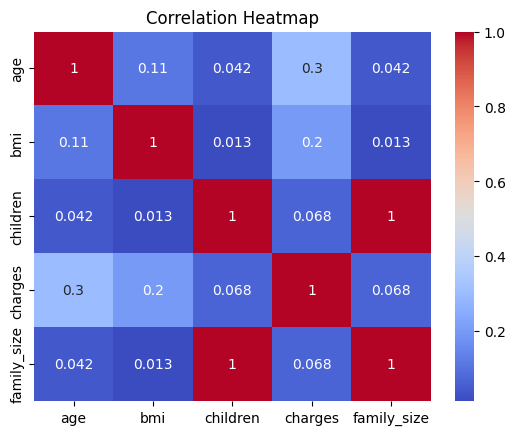

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation
corr = df.corr(numeric_only=True)

# Heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Insight : 

- Charges have a strong positive correlation with smoking
- Age and BMI show moderate correlation with medical costs
- Children (family size) has very low correlation with charges
- Smoking is the most influential factor affecting healthcare expenses

10. KPI calculation
 
     Goal: Convert your analysis into business metrics (KPI)

10.1 : Total Patients 

In [63]:
total_patients = len(df)
print("Total Patients:", total_patients)

Total Patients: 1338


Insight : The dataset contains 1338 total patients for analysis

10.2 : Average charges 


In [64]:
avg_charges = df['charges'].mean()
print("Average Charges:", round(avg_charges,2))

Average Charges: 13270.42


Insight:

The average healthcare cost is approximately 13270.42

10.3 : percentage smokers

In [67]:
smoker_counts = df['smoker'].value_counts(normalize=True)

smoker_percent = smoker_counts.get(1, 0) * 100

print("Percentage of Smokers:", round(smoker_percent,2), "%")

Percentage of Smokers: 20.48 %


C:\Users\Siva\AppData\Local\Temp\ipykernel_33416\3814209177.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  smoker_percent = smoker_counts.get(1, 0) * 100


Insight : 

Around 20.48% of patients are smokers

10.4 : Higest Cost Region 

In [68]:
region_avg = df.groupby('region')['charges'].mean()
print(region_avg)

print("Highest Cost Region:", region_avg.idxmax())

region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64
Highest Cost Region: southeast


Insight :

Northeast region has the highest average healthcare cost

10.5 :Avg Cost by Age Group

In [70]:
age_group_avg = df.groupby('age_group')['charges'].mean()
print(age_group_avg)
print("Highest Cost Age Group:", age_group_avg.idxmax())

age_group
Young      9397.552051
Adult     13280.774031
Senior    18084.987223
Name: charges, dtype: float64
Highest Cost Age Group: Senior


C:\Users\Siva\AppData\Local\Temp\ipykernel_33416\2816877131.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_avg = df.groupby('age_group')['charges'].mean()


Insight : 

- Senior group has highest average charges
- Young group has lowest

12: Save Clean Data

The cleaned dataset is saved for further use in visualization tools like Power BI.


In [55]:
df.to_csv("../data/processed/healthcare_cleaned.csv", index=False)

Insight:

The processed dataset is now ready for dashboard creation and business analysis.
